# Kompresja bitmapy RGB

## Zadanie

- Proszę wybrać kolorową bitmapę
- Proszę zamienić bitmapę na 3 macierze Red, Green, Blue (wartości z przedziału 0-255)
- Proszę napisać rekurencyjną kompresje macierzy z wykorzystaniem częściowego SVD dla wybranych parametrów $\sigma$= najmniejsza wartość osobliwa (wyrzucamy mniejsze) i $b$= maksymalny rank (liczba wartości osobliwych)
- Proszę zaimplementować rysowawcz skompresowanej macierzy
- Proszę zaimplementować rysowacz skompresowanej bitmapy

In [36]:
from dataclasses import dataclass
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.image import imread
from scipy.sparse.linalg import svds

np.random.seed(0)

In [37]:
from numpy.typing import NDArray
from typing import NewType, Any, Optional

ImageArray = NewType("ImageArray", NDArray[np.float32])
ChannelArray = NDArray[np.float32]

In [38]:
def load_image(file_path: str) -> ImageArray:
    image = imread(file_path).astype(np.float32) / 255
    assert image.ndim == 3 and image.shape[2] == 3, "Image must have shape (H, W, 3)"
    return ImageArray(image)

In [39]:
def extract_rgb(
    image: ImageArray,
) -> tuple[ChannelArray, ChannelArray, ChannelArray]:
    return image[..., 0], image[..., 1], image[..., 2]

In [40]:
def plot_channel(ax: Any, channel: ChannelArray, title: str) -> None:
    ax.imshow(channel, cmap="gray")
    ax.set_title(title)

In [41]:
def plot_image(image: ImageArray, title: str) -> None:
    _, axs = plt.subplots(2, 2, figsize=(10, 8), layout="tight")
    r, g, b = extract_rgb(image)
    plot_channel(axs[0, 0], image, title)
    plot_channel(axs[0, 1], r, "Red channel")
    plot_channel(axs[1, 0], g, "Green channel")
    plot_channel(axs[1, 1], b, "Blue channel")

In [42]:
def partial_svd(mat: NDArray, k: int) -> tuple[NDArray, NDArray, NDArray]:
    """
    Parameters
        A : ndarray
            Matrix to decompose of a floating point numeric dtype.
        k : int
            Number of singular values and singular vectors to compute.
            Must satisfy 1 <= k <= kmax, where kmax=min(M, N).

    Returns
        u : ndarray, shape=(M, k)
            Unitary matrix having left singular vectors as columns.
        s : ndarray, shape=(k,)
            The singular values (in ascending order).
        vt : ndarray, shape=(k, N)
            Unitary matrix having right singular vectors as rows.
    """
    return svds(mat, k=k)  # type: ignore

In [43]:
@dataclass
class CompressedNode:
    # Hierarchical SVD representation
    u: Optional[NDArray[np.float32]] = None
    s: Optional[NDArray[np.float32]] = None
    vt: Optional[NDArray[np.float32]] = None

    # Children nodes
    # tl | tr
    # ---|---
    # bl | br
    tl: Optional["CompressedNode"] = None  # top-left
    tr: Optional["CompressedNode"] = None  # top-right
    bl: Optional["CompressedNode"] = None  # bottom-left
    br: Optional["CompressedNode"] = None  # bottom-right

    # Helpers
    @property
    def is_leaf(self) -> bool:
        return (
            (self.tl is None)
            and (self.tr is None)
            and (self.bl is None)
            and (self.br is None)
        )

    @property
    def matrix(self) -> NDArray[np.float32]:
        if self.is_leaf:
            assert self.u is not None, "Matrix must be defined"
            assert self.s is not None, "Matrix must be defined"
            assert self.vt is not None, "Matrix must be defined"

            return np.clip(self.u @ np.diag(self.s) @ self.vt, 0.0, 1.0)
        else:
            assert self.tl is not None, "Top-left child must be defined"
            assert self.tr is not None, "Top-right child must be defined"
            assert self.bl is not None, "Bottom-left child must be defined"
            assert self.br is not None, "Bottom-right child must be defined"

            tl = self.tl.matrix
            tr = self.tr.matrix
            bl = self.bl.matrix
            br = self.br.matrix

            return np.block([[tl, tr], [bl, br]])

In [44]:
def create_tree(matrix: NDArray[np.float32], eps: float, r: int) -> CompressedNode:
    m, n = matrix.shape
    u, s, vt = partial_svd(matrix, r)
    node = CompressedNode(u, s, vt)

    if s[0] < eps or min(m, n) <= 2 * r + 1:
        return node

    m2, n2 = m // 2, n // 2
    node.tl = create_tree(matrix[:m2, :n2], eps, r)
    node.tr = create_tree(matrix[:m2, n2:], eps, r)
    node.bl = create_tree(matrix[m2:, :n2], eps, r)
    node.br = create_tree(matrix[m2:, n2:], eps, r)
    return node

In [45]:
def compress_image_demo(
    image: ImageArray,
    max_block_size: int,
    target_svd_components: int,
) -> ImageArray:
    """
    Parameters
        image : ImageArray
            Image to compress.
        max_block_size : int
            Maximum block size to use for the SVD decomposition.
            (maximal rank)
        target_svd_components : int
            Number of singular values to keep in the SVD decomposition.
            (discarad other singular values)
    Returns
        compressed_image : ImageArray
            Compressed image using the hierarchical SVD representation.
    """
    r_channel, g_channel, b_channel = extract_rgb(image)
    r_eps = np.linalg.svdvals(r_channel)
    g_eps = np.linalg.svdvals(g_channel)
    b_eps = np.linalg.svdvals(b_channel)

    max_eps = np.max([r_eps.shape, g_eps.shape, b_eps.shape])
    assert_message = f"`target_svd_components` > all singular values ({max_eps})"
    assert target_svd_components <= max_eps, assert_message

    root_r = create_tree(r_channel, r_eps[target_svd_components - 1], max_block_size)
    root_g = create_tree(g_channel, g_eps[target_svd_components - 1], max_block_size)
    root_b = create_tree(b_channel, b_eps[target_svd_components - 1], max_block_size)

    return ImageArray(np.stack((root_r.matrix, root_g.matrix, root_b.matrix), axis=-1))

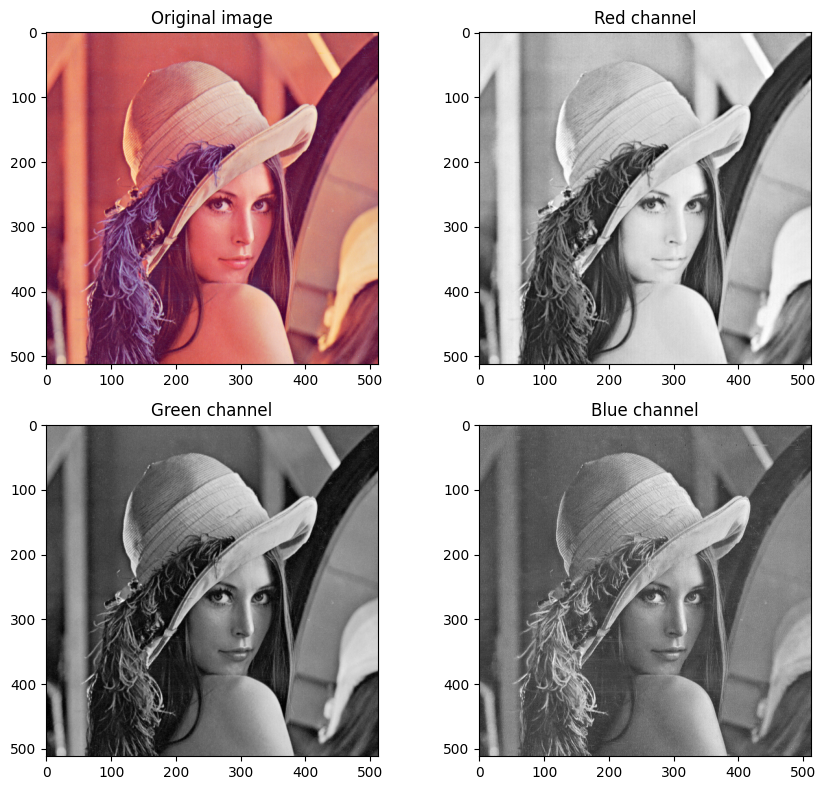

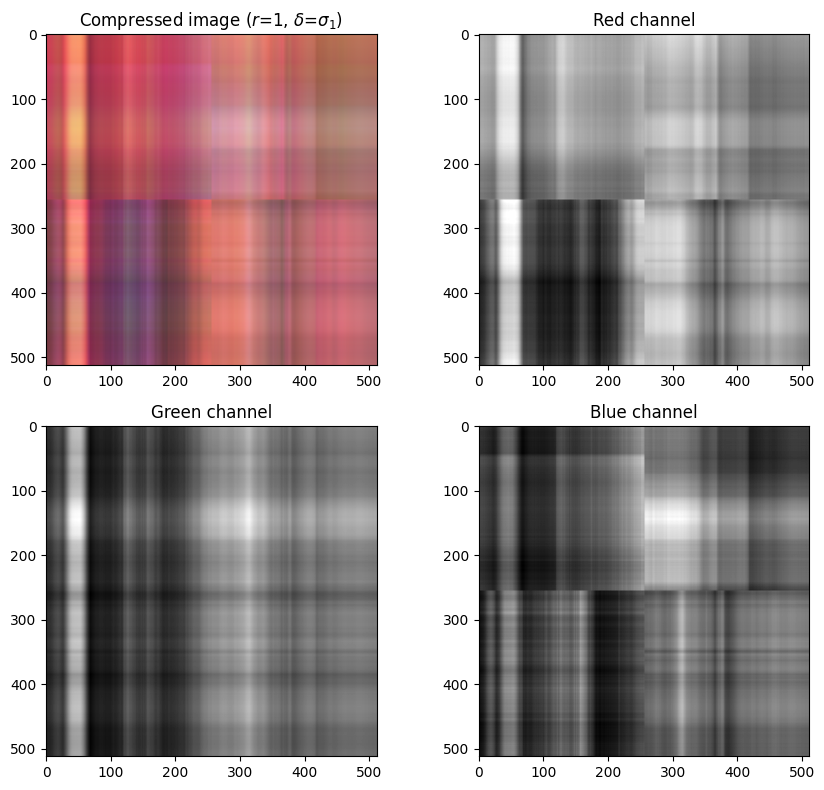

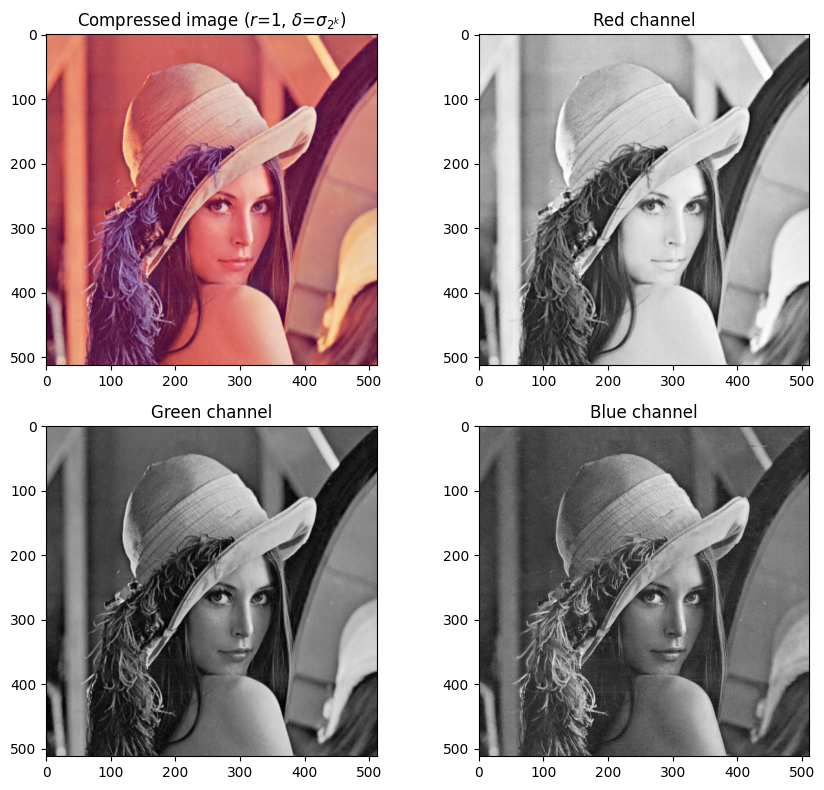

In [46]:
image = load_image(r"data/lena.bmp")
plot_image(image, "Original image")
compressed_image = compress_image_demo(image, 1, 1)
plot_image(compressed_image, r"Compressed image ($r$=1, $\delta$=$\sigma_{1}$)")
compressed_image = compress_image_demo(image, 1, 0)
plot_image(compressed_image, r"Compressed image ($r$=1, $\delta$=$\sigma_{2^k}$)")
# compressed_image = compress_image_demo(image, 1, 256)
# plot_image(compressed_image, r"Compressed image ($r$=1, $\delta$=$\sigma_{2^k/2}$)")
# compressed_image = compress_image_demo(image, 4, 1)
# plot_image(compressed_image, r"Compressed image ($r$=4, $\delta$=$\sigma_{1}$)")
# compressed_image = compress_image_demo(image, 4, 0)
# plot_image(compressed_image, r"Compressed image ($r$=4, $\delta$=$\sigma_{2^k}$)")
# compressed_image = compress_image_demo(image, 4, 256)
# plot_image(compressed_image, r"Compressed image ($r$=4, $\delta$=$\sigma_{2^k/2}$)")

In [47]:
assert False
image = load_image(r"data/100zloty.jpg")
plot_image(image, "Original image")
compressed_image = compress_image_demo(image, 1, 1)
plot_image(compressed_image, r"Compressed image ($r$=1, $\delta$=$\sigma_{1}$)")
compressed_image = compress_image_demo(image, 1, 0)
plot_image(compressed_image, r"Compressed image ($r$=1, $\delta$=$\sigma_{2^k}$)")
compressed_image = compress_image_demo(image, 1, 423)
plot_image(compressed_image, r"Compressed image ($r$=1, $\delta$=$\sigma_{2^k/2}$)")
compressed_image = compress_image_demo(image, 4, 1)
plot_image(compressed_image, r"Compressed image ($r$=4, $\delta$=$\sigma_{1}$)")
compressed_image = compress_image_demo(image, 4, 0)
plot_image(compressed_image, r"Compressed image ($r$=4, $\delta$=$\sigma_{2^k}$)")
compressed_image = compress_image_demo(image, 4, 423)
plot_image(compressed_image, r"Compressed image ($r$=4, $\delta$=$\sigma_{2^k/2}$)")

AssertionError: 